<a href="https://colab.research.google.com/github/su92-msaiw-f25-006-boop/lessons-learned/blob/main/Crop_Disease_Detection_Using(CRNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    Flatten, BatchNormalization, Input, LSTM, GRU, TimeDistributed
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


Mounted at /content/drive


In [2]:
BASE_DIR = '/content/drive/MyDrive/PlantVillage_Splits'

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'val')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-4


In [3]:
train_ds = image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical', seed=42
)

val_ds = image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical', seed=42
)

test_ds = image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical', shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Detected Classes:", class_names)
print("Total Classes:", NUM_CLASSES)


Found 14446 files belonging to 15 classes.
Found 3096 files belonging to 15 classes.
Found 3096 files belonging to 15 classes.
Detected Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Total Classes: 15


In [4]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))
val_ds   = val_ds.map(lambda x, y: (x / 255.0, y))
test_ds  = test_ds.map(lambda x, y: (x / 255.0, y))

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)


In [5]:
inputs = Input(shape=(128, 128, 3))

# CNN Feature Extraction
x = Conv2D(32, 3, activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D(2)(x)

x = Conv2D(64, 3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2)(x)

x = Conv2D(128, 3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2)(x)

x = Conv2D(256, 3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2)(x)

# Reshape for RNN: (batch_size, timesteps, features)
# Here we treat rows of feature maps as timesteps
x = tf.keras.layers.Reshape((8, 256*8))(x)  # (batch, timesteps=8, features=2048)

# RNN Layer (GRU)
x = GRU(256, return_sequences=False)(x)  # final output

# Dense Layers for classification
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 2048)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 256)            │     1,771,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,230,991 (8.51 MB)

 Trainable params: 2,230,031 (8.51 MB)

 Non-trainable params: 960 (3.75 KB)

In [6]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_crnn_model.keras', monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)


In [7]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Epoch 1/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 2807s 6s/step - accuracy: 0.3873 - loss: 1.9405 - val_accuracy: 0.2494 - val_loss: 2.6231 - learning_rate: 1.0000e-04
Epoch 2/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 127s 280ms/step - accuracy: 0.6603 - loss: 1.0478 - val_accuracy: 0.3970 - val_loss: 2.0712 - learning_rate: 1.0000e-04
Epoch 3/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 128s 283ms/step - accuracy: 0.7458 - loss: 0.7884 - val_accuracy: 0.5346 - val_loss: 1.4863 - learning_rate: 1.0000e-04
Epoch 4/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 129s 285ms/step - accuracy: 0.8079 - loss: 0.6017 - val_accuracy: 0.6453 - val_loss: 1.1072 - learning_rate: 1.0000e-04
Epoch 5/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 129s 283ms/step - accuracy: 0.8394 - loss: 0.5053 - val_accuracy: 0.7112 - val_loss: 0.8833 - learning_rate: 1.0000e-04
Epoch 6/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 128s 282ms/step - accuracy: 0.8577 - loss: 0.4452 - val_accuracy: 0.4868 - val_loss: 2.0742 - learning_rate: 1.0000e-04
Epoch 7/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 14

In [8]:
MODEL_PATH = "/content/drive/MyDrive/PlantVillage_CRNN_Model.keras"
model.save(MODEL_PATH)
print("✅ Model saved successfully")


✅ Model saved successfully


In [9]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"🔥 Test Accuracy: {test_acc*100:.2f}%")


97/97 ━━━━━━━━━━━━━━━━━━━━ 465s 5s/step - accuracy: 0.8738 - loss: 0.4060
🔥 Test Accuracy: 82.56%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 

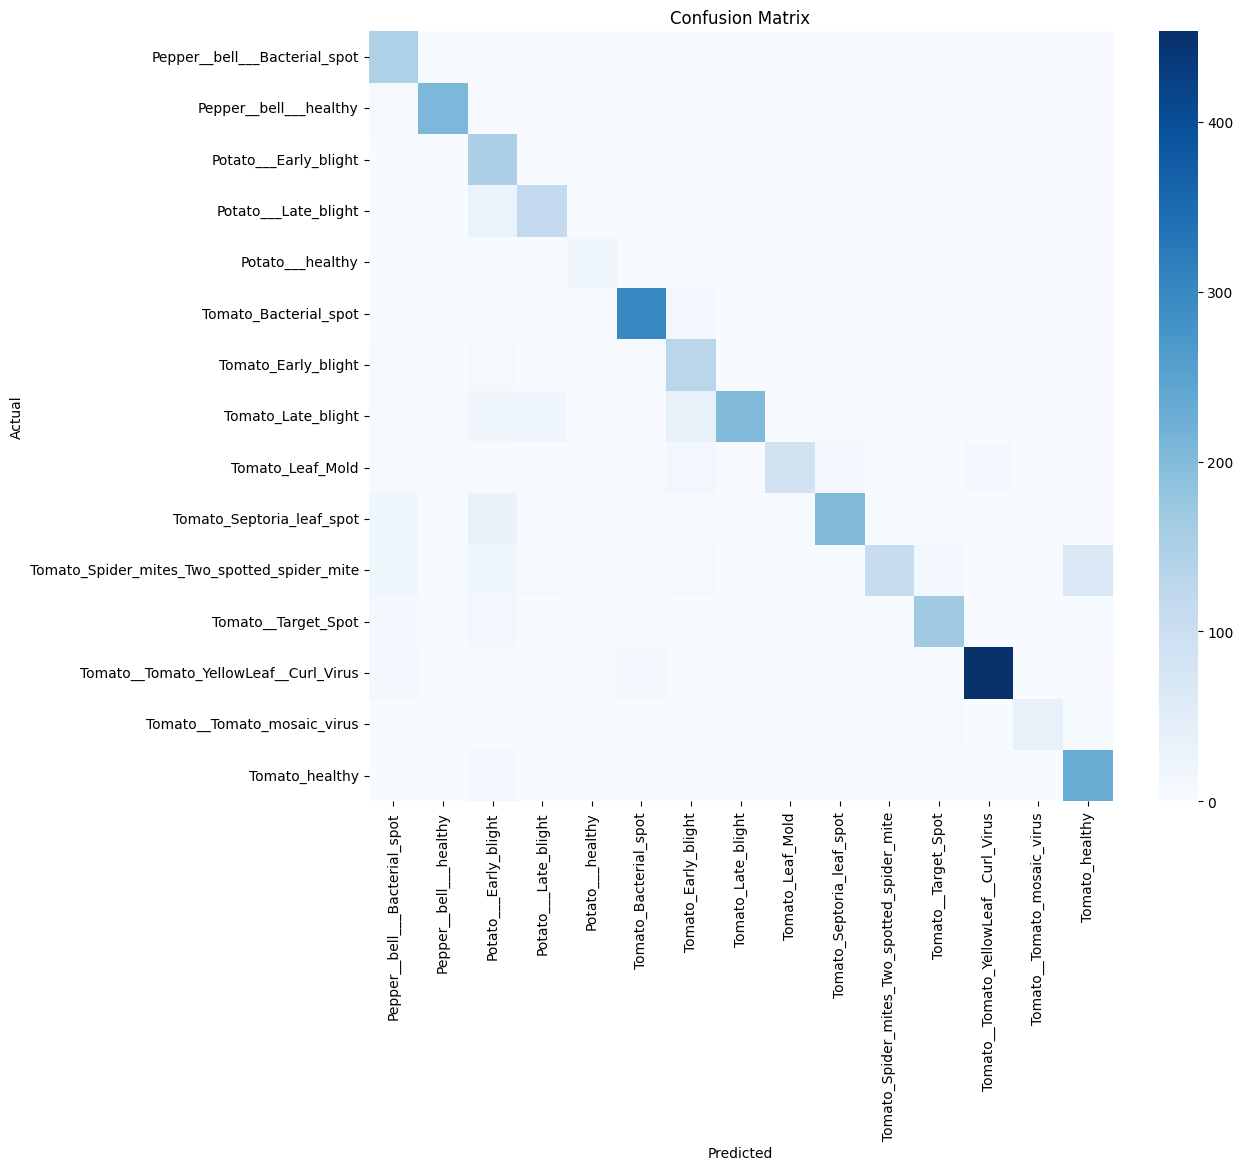

In [10]:
y_true, y_pred = [], []

for x, y in test_ds:
    preds = model.predict(x)
    y_true.extend(np.argmax(y.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = tf.math.confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


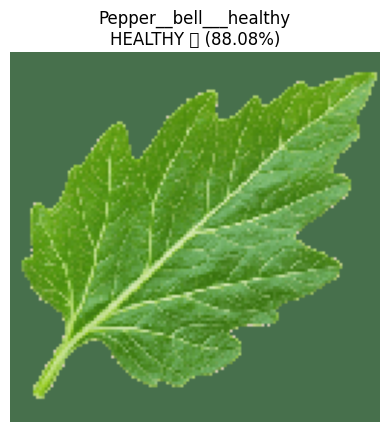

Predicted Class : Pepper__bell___healthy
Status          : HEALTHY ✅
Confidence      : 88.08%


In [14]:
IMAGE_PATH = "/content/drive/MyDrive/test_image/test4.png"

img = tf.keras.preprocessing.image.load_img(IMAGE_PATH, target_size=IMG_SIZE)
img_arr = tf.keras.preprocessing.image.img_to_array(img) / 255.0
img_arr = np.expand_dims(img_arr, axis=0)

pred = model.predict(img_arr)
idx = np.argmax(pred[0])
predicted_class = class_names[idx]
confidence = np.max(pred[0]) * 100

status = "HEALTHY ✅" if "healthy" in predicted_class.lower() else "DISEASED ❌"

plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class}\n{status} ({confidence:.2f}%)")
plt.show()

print("Predicted Class :", predicted_class)
print("Status          :", status)
print(f"Confidence      : {confidence:.2f}%")
